# Progetto Finale - Sistemi Complessi

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

Il seguente notebook ha lo scopo di replicare i risultati numerici riportati nell'articolo "CA Modeling of Ant-Traffic on Trails", pubblicato nel 2010 su Springer Nature da Debashish Chowdhury, Katsuhiro Nishinari e Andreas Schadschneider .

Il paper in questione si occupa di simulare il comportamento di una colonia di formiche in un ambiente complesso, come quello di un sentiero, utilizzando un modello di automi cellulari.

## Caratteristiche del modello

Il modello proposto dagli autori è un modello di automi cellulari, in cui ogni cella della griglia rappresenta un punto del sentiero. Le formiche possono muoversi in un'unica direzione, e sono influenzate dalla presenza dei feromoni lasciati dalle altre formiche. Ogni cella ha due variabili di stato $S$ e $\sigma$, che rappresentano rispettivamente la presenza di una formica e la presenza di un feromone; esse possono assumere valori binari, 0 o 1.
Le celle sono numerate da 0 a $L-1$, dove $L$ è la lunghezza del sentiero. Le formiche si muovono in una direzione, da 0 a $L-1$. La probabilità che una formica si muova dalla cella $i$ alla cella $i+1$ è data da:
$$
P_{i \rightarrow i+1} = \begin{cases} Q & \text{se } \sigma_{i+1}(t) = 1 \\ q & \text{se } \sigma_{i+1}(t) = 0 \end{cases}
$$
Dunque la probabilità che una formica si muova in avanti è maggiore se la cella successiva contiene un feromone. Non può essere presente più di una formica in una cella, quindi la probabilità che una formica si muova in una cella con $S(t) = 1$ è nulla.

Una formica che si muove in una nuova cella crea un feromone in quella cella.
$$
\sigma_i(t+1) = 1 \text{ se } S_i(t+1) = 1
$$

I fermoni si dissolvono nel tempo, con una probabilità $f$, quindi la presenza di un feromone in una cella senza formica è data da:
$$
\sigma_i(t+1) =
\begin{cases}
0 & \text{con probabilità $f$ se $\sigma_i(t) = 1$ e $S_i(t+1) = 0$} \\
0 & \text{se $\sigma_i(t) = 0$ e $S_i(t+1) = 0$} \\
1 & \text{con probabilità $1-f$ se $\sigma_i(t) = 1$ e $S_i(t+1) = 0$} \\
1 & \text{se $S_i(t+1) = 1$}
\end{cases}
$$

Il modello può essere quindi riassunto dalle equazioni:
$$
S_i(t+1) = S_i(t) + \min(\eta_{i-1}(t), S_{i-1}(t), 1 - S_i(t)) - \min(\eta_i(t), S_i(t), 1 - S_{i+1}(t)) \\
\sigma_i(t+1) = \max(S_i(t+1), \min(\sigma_i(t), \xi_i(t)))
$$
dove $\eta$ e $\xi$ sono variabili casuali che rappresentano rispettivamente la probabilità che un feromone si dissolva e la probabilità che una formica si muova:
$$
\xi_i(t) = \begin{cases}
0 & \text{con probabilità $f$} \\
1 & \text{con probabilità $1-f$}
\end{cases} \\
\eta_i(t) = \begin{cases}
0 & \text{con probabilità $p = q + (Q-q)\sigma_{i+1}(t)$} \\
1 & \text{con probabilità $1-p$}
\end{cases}
$$



$$

In [ ]:
def stop_trail(S):
    for i in range(len(S) - 1):
        if S[i] == 1 and S[i + 1] != 1:
            return False
    return True

In [ ]:
def plot_lattice(S, sigma, t, L):
    visual = ["A" if S[i] == 1 else ("•" if sigma[i] == 1 else "_") for i in range(L)]
    print(f"Step {t}: {''.join(visual)}")


In [ ]:
def single_direction(L, q, Q, f, density):

    np.random.seed(42)

    num_ants = int(density * L)
    S = np.zeros(L)
    sigma = np.zeros(L)

    # Popolazione iniziale randomica

    for i in range(num_ants):
        S[np.random.randint(0, L)] = 1

    step = 0


    while not stop_trail(S):

        S_new = np.copy(S)

        for i in range(L-2, -1, -1):  # Scansiona da destra a sinistra
            if S[i] == 1 and S[i+1] == 0:  # Se la formica può muoversi
                p_eff = Q if sigma[i+1] == 1 else q  # Controllo feromone
                if np.random.rand() < p_eff:
                    S_new[i] = 0
                    S_new[i+1] = 1
                    sigma[i] = 1  # Deposizione del feromone

        S = S_new

        # Evaporazione dei feromoni
        for i in range(L):
            if sigma[i] == 1 and np.random.rand() < f:
                sigma[i] = 0

        step += 1
        plot_lattice(S, sigma, step, L)

In [ ]:
# Parametri per simulare

L = 500
q = 0.25 # Probabilità di movimento se non c'è feromone nella cella successiva
Q = 0.75 # Probabilità di movimento se c'è feromone nella cella successiva
f = 0.0005 # Probabilità di evaporazione del feromone
density = 0.3 # Densità di formiche

In [ ]:
single_direction(L, q, Q, f, density)

Step 1: _•A_____A____AA_____AA____________•A____A__A____AAA_AAA___•A__A_A______A________A______AA__A_______•A_A__A•A_____________A______A_A___AA__A__________A_A____•A__AAA___A__A____A____________AAAA•A________A___A_•A___A_•AAA____________A____A•A___•A•A______AA____A_AA__AA____A•A_A__A__•A_______A____A_A____A__•A_A_AA___A_•A__A______•AA_A______A_A___AAA__A_•A_______A___A__•A____A_____AA_____A_A_•AA_________•A______A___•A___AA_______•A_A____A_______A_A________AA__AA_A_A__A____A__AA•A_____AA____A_AA_____A_
Step 2: _•A_____A____AA_____AA____________•A____A__•A___AAA_AAA___•A__A_•A_____A________A______AA__A_______••AA__•AA_____________•A_____•AA___A•A_•A_________A_A____•A__AAA___A__A____•A___________AAAA•A________A___A_•A___A_•AA•A___________•A___A•A___••AA______AA____A_A•A_AA____•AA_A__A__•A_______A____A_A____A__•A_A_A•A__A_•A__A______•A•AA______A_A___AAA__A_•A_______A___A__•A____A_____AA_____A_A_•AA_________•A______A___•A___A•A______•A_•A___•A______A_A________AA__AA_A_A__A____A__A•AA_____

Definiamo il flusso come:
$$
J = \rho v
$$
dove $\rho$ è la densità di formiche e $v$ è la velocità media delle formiche. La densità di formiche è data in input, mentre la velocità media è calcolata come:
$$
v = \frac{1}{L} \sum_{i=0}^{L-1} \langle S_i(t+1) - S_i(t) \rangle
$$
ovvero la media della variazione di formiche in una cella.

In [ ]:
def single_direction_velocity(L, q, Q, f, density):

    np.random.seed(42)

    num_ants = int(density * L)
    S = np.zeros(L)
    sigma = np.zeros(L)

    # Popolazione iniziale randomica
    for i in range(num_ants):
        S[np.random.randint(0, L)] = 1

    step = 0
    total_moves = 0

    while not stop_trail(S):
        S_new = np.copy(S)
        step_moves = 0

        for i in range(L-2, -1, -1):  # Scansiona da destra a sinistra
            if S[i] == 1 and S[i+1] == 0:  # Se la formica può muoversi
                p_eff = Q if sigma[i+1] == 1 else q  # Controllo feromone
                if np.random.rand() < p_eff:
                    S_new[i] = 0
                    S_new[i+1] = 1
                    sigma[i] = 1  # Deposizione del feromone
                    step_moves += 1

        S = S_new

        # Evaporazione dei feromoni
        for i in range(L):
            if sigma[i] == 1 and np.random.rand() < f:
                sigma[i] = 0

        step += 1
        total_moves += step_moves

    avg_velocity = (total_moves / (num_ants * step)) if step > 0 else 0  # Velocità media
    return avg_velocity

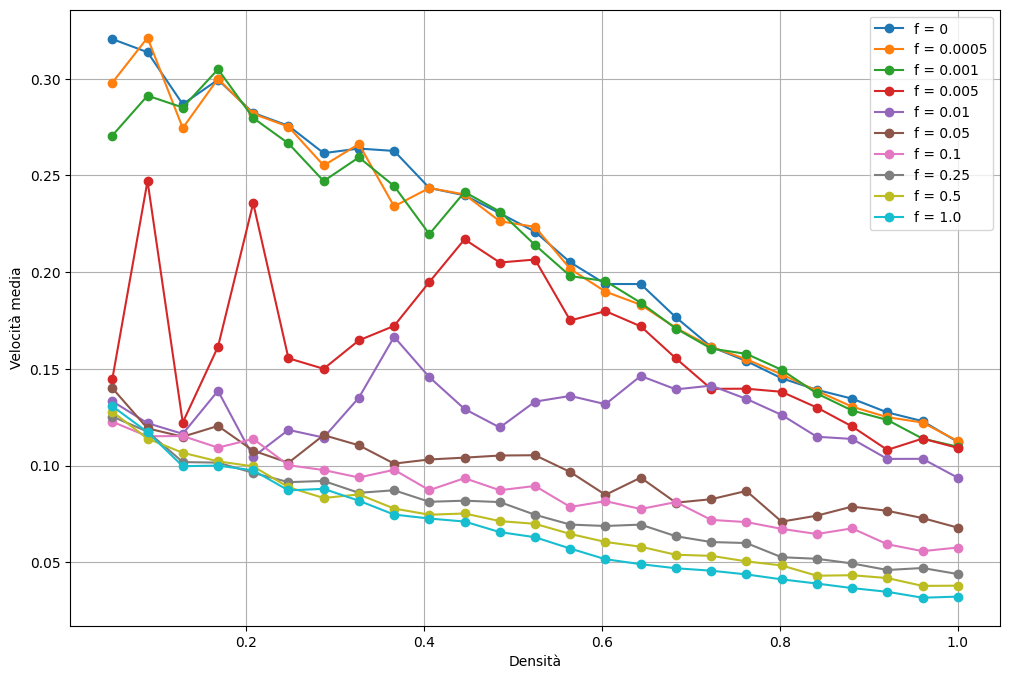

In [ ]:
# Calcoliamo la velocità media per una serie di valori di f e di densità
densities = np.linspace(0.05, 1.00, 25)
f_values = [0, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

velocities = np.zeros((len(f_values), len(densities)))

for i, f in enumerate(f_values):
    for j, density in enumerate(densities):
        velocities[i, j] = single_direction_velocity(L, q, Q, f, density)

# Plot
plt.figure(figsize=(12, 8))
for i, f in enumerate(f_values):
    plt.plot(densities, velocities[i], label=f"f = {f}", marker="o", linestyle="-")
plt.xlabel("Densità")
plt.ylabel("Velocità media")
plt.legend()
plt.grid()
plt.show()


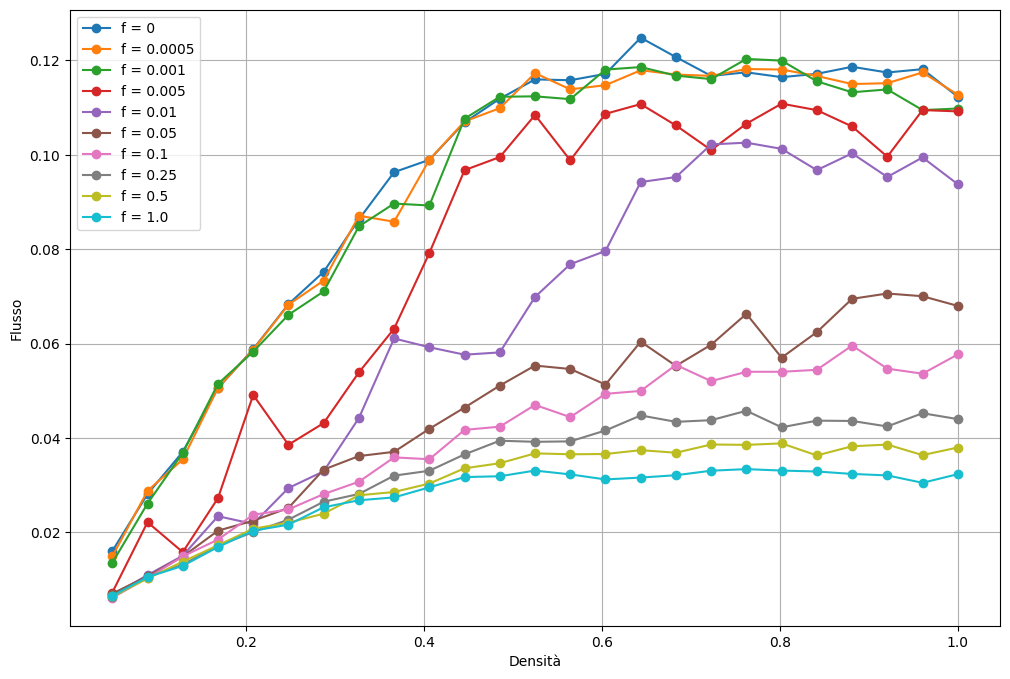

In [ ]:
# Calcoliamo il flusso per una serie di valori di f e di densità

flows = np.zeros((len(f_values), len(densities)))

for i, f in enumerate(f_values):
    for j, density in enumerate(densities):
        flows[i, j] = velocities[i, j] * density

# Plot
plt.figure(figsize=(12, 8))
for i, f in enumerate(f_values):
    plt.plot(densities, flows[i], label=f"f = {f}", marker="o", linestyle="-")
plt.xlabel("Densità")
plt.ylabel("Flusso")
plt.legend()
plt.grid()
plt.show()

## Caratteristiche del modello bidirezionale

Il modello bidirezionale estende il modello unidirezionale introducendo formiche che si muovono in direzioni opposte. In questo caso, ogni cella può essere occupata da una formica che si muove verso destra ($S_R$) o da una formica che si muove verso sinistra ($S_L$), ma non da entrambe contemporaneamente. Le variabili di stato sono $S_R$, $S_L$, e $\sigma$, che rappresentano rispettivamente la presenza di una formica che si muove a destra, una formica che si muove a sinistra e la presenza di un feromone. Anche in questo caso, le variabili sono binarie.

Le formiche che si muovono verso destra (da 0 a $L-1$) seguono le stesse regole di probabilità di movimento del modello unidirezionale, ma possono muoversi solo in celle vuote (dove $S_R=0$ e $S_L=0$).
$$
P_{i \rightarrow i+1} = \begin{cases} Q & \text{se } \sigma_{i+1}(t) = 1 \\ q & \text{se } \sigma_{i+1}(t) = 0 \end{cases} \text{ se } S_{i+1}(t) = 0 \text{ e } S_{L,i+1}(t) = 0
$$

Analogamente, le formiche che si muovono verso sinistra (da $L-1$ a 0) hanno una probabilità di movimento maggiore se la cella precedente contiene un feromone e possono muoversi solo in celle vuote (dove $S_R=0$ e $S_L=0$).
$$
P_{i \rightarrow i-1} = \begin{cases} Q & \text{se } \sigma_{i-1}(t) = 1 \\ q & \text{se } \sigma_{i-1}(t) = 0 \end{cases} \text{ se } S_{i-1}(t) = 0 \text{ e } S_{R,i-1}(t) = 0
$$

Quando una formica si muove in una nuova cella, deposita un feromone in quella cella:
$$
\sigma_i(t+1) = 1 \text{ se } S_{R,i}(t+1) = 1 \text{ o } S_{L,i}(t+1) = 1
$$

I feromoni si dissolvono con probabilità $f$, come nel modello unidirezionale.

Una caratteristica aggiuntiva del modello bidirezionale è la possibilità che formiche che si muovono in direzioni opposte scambino di posto se si incontrano su celle adiacenti. Questo avviene con una probabilità $K$. Se una formica che si muove a destra si trova nella cella $i$ ($S_{R,i}=1$) e una formica che si muove a sinistra si trova nella cella $i+1$ ($S_{L,i+1}=1$), con probabilità $K$ scambieranno le loro posizioni ($S_{R,i+1}=1$ e $S_{L,i}=1$) e le celle originali diventeranno vuote ($S_{R,i}=0$ e $S_{L,i+1}=0$).

Le equazioni del modello bidirezionale sono più complesse a causa dell'interazione tra le due direzioni e lo scambio di posizione, ma i principi fondamentali di movimento basato sui feromoni e l'evaporazione rimangono gli stessi. La simulazione numerica di questo modello permette di studiare come la densità delle formiche e la probabilità di scambio influenzano il flusso bidirezionale sul sentiero.

In [ ]:
def stop_double_trail(S_R, S_L):
    for i in range(len(S_R) - 1):
        if S_R[i] == 1 and S_R[i + 1] != 1:
            return False
    for i in range(len(S_L) - 1):
        if S_L[i] != 1 and S_L[i+1] == 1:
            return False
    return True

In [ ]:
def plot_double_lattice(S_R, S_L, sigma, t, L):
    visual = ['R' if S_R[i] == 1 else ('L' if S_L[i] == 1 else ('•' if sigma[i] == 1 else '_')) for i in range(L)]
    print(f"Step {t}: {''.join(visual)}")

In [ ]:
def double_direction(L, q, Q, f, K, density):

    np.random.seed(42)

    num_ants = int(density * L)
    S_R = np.zeros(L)
    S_L = np.zeros(L)
    sigma = np.zeros(L)

    # Popolazione iniziale randomica, o c'è una S_R o c'è una S_L
    for i in range(num_ants):
        if np.random.rand() < 0.5:
            S_R[np.random.randint(0, L)] = 1
        else:
            S_L[np.random.randint(0, L)] = 1

    step = 0

    while not stop_double_trail(S_R, S_L):

        S_R_new = np.copy(S_R)
        S_L_new = np.copy(S_L)

        # Movimento delle formiche S_R (verso destra)
        for i in range(L-2, -1, -1):
            if S_R[i] == 1 and S_R[i+1] == 0 and S_L[i+1] == 0:  # Se la formica può muoversi
                p_eff = Q if sigma[i+1] == 1 else q  # Controllo feromone
                if np.random.rand() < p_eff:
                    S_R_new[i] = 0
                    S_R_new[i+1] = 1
                    sigma[i] = 1  # Deposizione del feromone

        # Movimento delle formiche S_L (verso sinistra)
        for i in range(1, L):
            if S_L[i] == 1 and S_L[i-1] == 0 and S_R[i-1] == 0:  # Se la formica può muoversi
                p_eff = Q if sigma[i-1] == 1 else q  # Controllo feromone
                if np.random.rand() < p_eff:
                    S_L_new[i] = 0
                    S_L_new[i-1] = 1
                    sigma[i] = 1 # Deposizione del feromone

         # Scambio di posizione tra S_R e S_L con probabilità K
        for i in range(L-1):
            if S_R[i] == 1 and S_L[i+1] == 1:
                if np.random.rand() < K:
                    S_R_new[i], S_L_new[i+1] = 0, 0
                    S_R_new[i+1], S_L_new[i] = 1, 1

        S_R = S_R_new
        S_L = S_L_new

        # Evaporazione dei feromoni
        for i in range(L):
            if sigma[i] == 1 and np.random.rand() < f:
                sigma[i] = 0

        step += 1

        plot_double_lattice(S_R, S_L, sigma, step, L)

In [ ]:
# Parametri per simulare

L = 500
q = 0.25 # Probabilità di movimento se non c'è feromone nella cella successiva
Q = 0.75 # Probabilità di movimento se c'è feromone nella cella successiva
f = 0.0005 # Probabilità di evaporazione del feromone
K = 0.5 # Probabilità di scambio di traccia
density = 0.3 # Densità di formiche

In [ ]:
double_direction(L, q, Q, f, K, density)

Step 1: _LR____L•____________L_____L____R_RLL•R_L__L____RLRLLR•R_______________R________•R___•RRR______R_RLLR_L_________L_______L__L____RL•___L_L_____LR__LR_L_________RRLL___•R_L_R___R___L_______R_R_______R____L__R_•R_____•RL•_____RR_____R_L________L___L•____L•L_________R__LR___________L_L•R________LL______R__L___L_L____•R_________LLR_________R_•R__RLR_LR__R_______R_____LR___R_____RL•______R_L___RR_L__R_LRLR•RLLRL•____R____R_R_L________________L__RR•R___R________RRR_L_______RR__________R____________R_LR
Step 2: _LR____L•____________L_____L____R_LRL•RL•_L•____LRLRLLR•R______________R________•R___•RRR______R_LRLR_L_________L______L•__L____LR•___LL•_____LLR_LR_L_________RRLL___•RL•_•R__R___L_______R_R_______R____L__•R•R_____•RL•_____RR_____R_L________L___L•____L•L_________R__LR__________L•_L•R________LL______R_L•___LL•____••R________LLR_________R_•R__RLR_LR__R_______R____L•R___R_____RL•______R_L___RR_L__•RLRL•RRLLLR•____•R___R_•RL________________L__R•RR___R________RRR_L_______RR__________

In [ ]:
def double_direction_velocity(L, q, Q, f, K, density):

    np.random.seed(42)

    num_ants = int(density * L)

    S_R = np.zeros(L)
    S_L = np.zeros(L)
    sigma = np.zeros(L)

    # Popolazione iniziale randomica, o c'è una S_R o c'è una S_L
    for i in range(num_ants):
        if np.random.rand() < 0.5:
            S_R[np.random.randint(0, L)] = 1
        else:
            S_L[np.random.randint(0, L)] = 1

    step = 0
    total_moves = 0

    while not stop_double_trail(S_R, S_L):

        S_R_new = np.copy(S_R)
        S_L_new = np.copy(S_L)
        step_moves = 0

        # Movimento delle formiche S_R (verso destra)
        for i in range(L-2, -1, -1):
            if S_R[i] == 1 and S_R[i+1] == 0 and S_L[i+1] == 0:
                p_eff = Q if sigma[i+1] == 1 else q
                if np.random.rand() < p_eff:
                    S_R_new[i] = 0
                    S_R_new[i+1] = 1
                    sigma[i] = 1
                    step_moves += 1

        # Movimento delle formiche S_L (verso sinistra)
        for i in range(1, L):
            if S_L[i] == 1 and S_L[i-1] == 0 and S_R[i-1] == 0:
                p_eff = Q if sigma[i-1] == 1 else q
                if np.random.rand() < p_eff:
                    S_L_new[i] = 0
                    S_L_new[i-1] = 1
                    sigma[i] = 1
                    step_moves += 1

        # Scambio di posizione tra S_R e S_L con probabilità K
        for i in range(L-1):
            if S_R[i] == 1 and S_L[i+1] == 1:
                if np.random.rand() < K:
                    S_R_new[i], S_L_new[i+1] = 0, 0
                    S_R_new[i+1], S_L_new[i] = 1, 1
                    step_moves += 2

        S_R = S_R_new
        S_L = S_L_new

        # Evaporazione dei feromoni
        for i in range(L):
            if sigma[i] == 1 and np.random.rand() < f:
                sigma[i] = 0

        step += 1
        total_moves += step_moves

    avg_velocity = (total_moves / (num_ants * step)) if step > 0 else 0  # Velocità media
    return avg_velocity



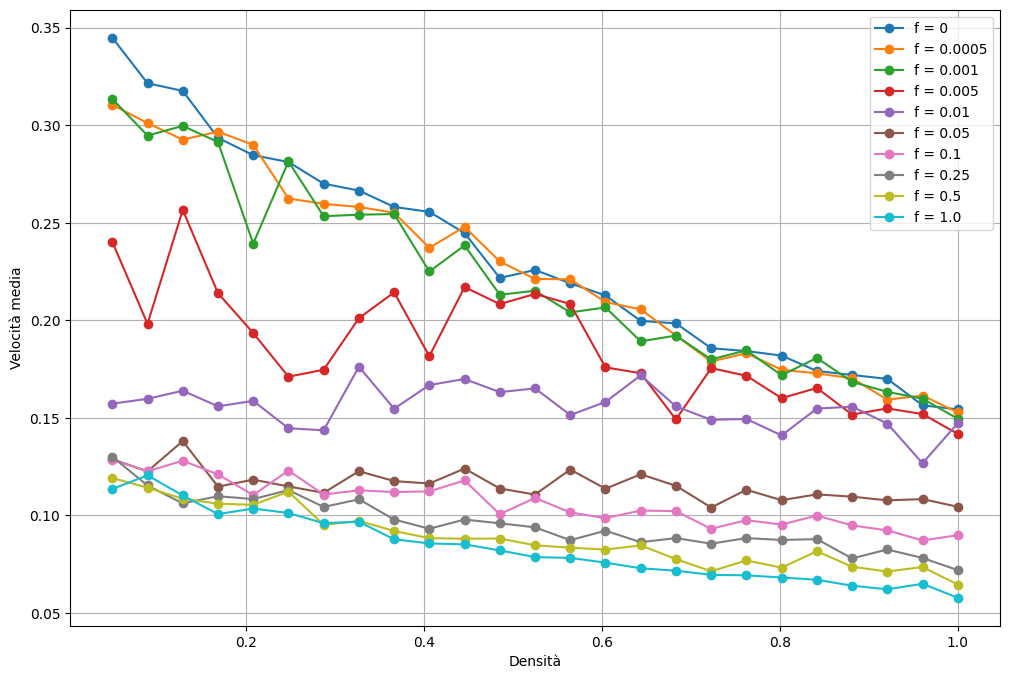

In [ ]:
# Calcoliamo la velocità media per una serie di valori di f e di densità

densities = np.linspace(0.05, 1.00, 25)
f_values = [0, 0.0005, 0.001, 0.005, 0.01, 0.05, 0.10, 0.25, 0.50, 1.00]

velocities = np.zeros((len(f_values), len(densities)))

for i, f in enumerate(f_values):
    for j, density in enumerate(densities):
        velocities[i, j] = double_direction_velocity(L, q, Q, f, K, density)

# Plot
plt.figure(figsize=(12, 8))
for i, f in enumerate(f_values):
    plt.plot(densities, velocities[i], label=f"f = {f}", marker="o", linestyle="-")
plt.xlabel("Densità")
plt.ylabel("Velocità media")
plt.legend()
plt.grid()
plt.show()

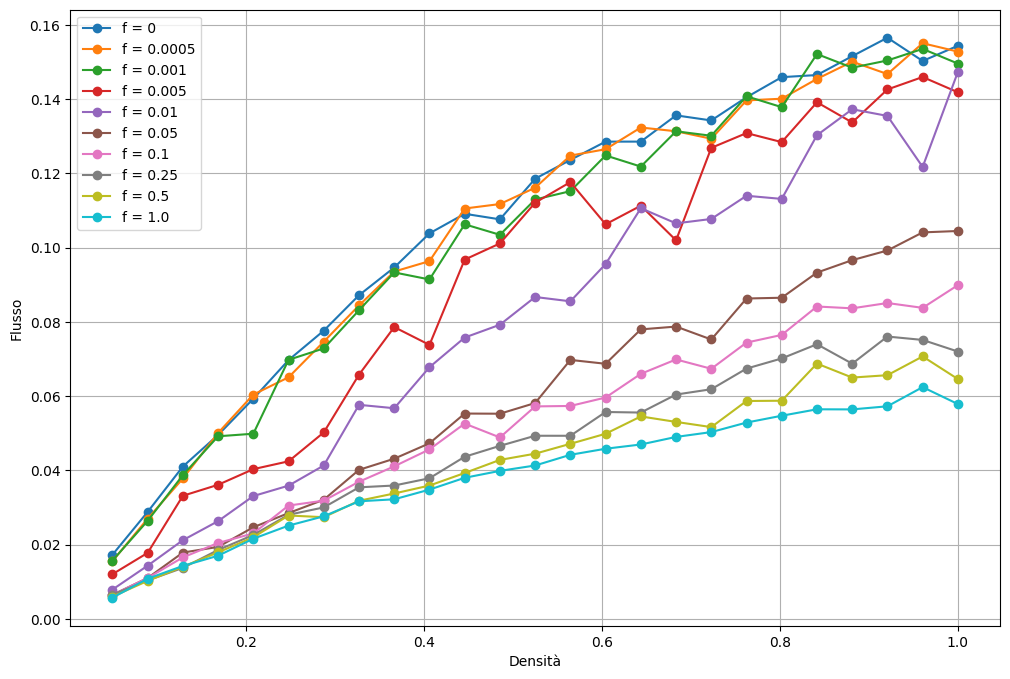

In [ ]:
# Calcoliamo il flusso per una serie di valori di f e di densità

flows = np.zeros((len(f_values), len(densities)))

for i, f in enumerate(f_values):
    for j, density in enumerate(densities):
        flows[i, j] = velocities[i, j] * density

# Plot
plt.figure(figsize=(12, 8))
for i, f in enumerate(f_values):
    plt.plot(densities, flows[i], label=f"f = {f}", marker="o", linestyle="-")
plt.xlabel("Densità")
plt.ylabel("Flusso")
plt.legend()
plt.grid()
plt.show()